# Cuadernillo grafico: percepcion publica sobre IA

Este notebook procesa `data_2/ATP W152.csv`, correspondiente a la Wave 152 del American Trends Panel de Pew Research Center. Segun el PDF `data_2/ATP W152 Methodology.pdf`, la encuesta se aplico del 12 al 18 de agosto de 2024 a 5.410 adultos de Estados Unidos.

Como la metodologia indica sobremuestras de algunos grupos y posterior calibracion, todos los porcentajes se calculan con `WEIGHT_W152`. Los codigos `99` se tratan como no respuesta y se excluyen del denominador de cada pregunta. Las etiquetas de preguntas/respuestas se toman del topline oficial de Pew de la misma wave.

In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

DATA_PATH = Path("data_2/ATP W152.csv")
OUTPUT_DIR = Path("data_2/graficos_percepcion_ia")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 180,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

WEIGHT = "WEIGHT_W152"
MISSING_CODES = {99, 98, 97}

single_labels = {
    "AI_HEARD_W152": {1: "Mucho", 2: "Un poco", 3: "Nada"},
    "CNCEXC_W152": {1: "Mas entusiasmo", 2: "Mas preocupacion", 3: "Ambos por igual"},
    "USEAI_W152": {1: "Casi constantemente", 2: "Varias veces al dia", 3: "Una vez al dia", 4: "Varias veces por semana", 5: "Menos seguido"},
    "AICONTROL1_W152": {1: "Mucho", 2: "Bastante", 3: "Algo", 4: "No mucho", 5: "Nada"},
    "AICONTROL2_W152": {1: "Comodo con el control actual", 2: "Quisiera mas control", 3: "No esta seguro"},
    "AICHANGE_W152": {1: "Muy positivo", 2: "Algo positivo", 3: "Positivo y negativo", 4: "Algo negativo", 5: "Muy negativo", 6: "No esta seguro"},
    "AIJOBS_W152": {1: "Mas empleos", 2: "Menos empleos", 3: "No cambiara mucho", 4: "No esta seguro"},
    "PERSBENHRM_W152": {1: "Mas probable que perjudique", 2: "Mas probable que beneficie", 3: "No esta seguro"},
    "TRSTAIPRS_W152": {1: "Si", 2: "No", 3: "No esta seguro"},
    "AIREG_W152": {1: "Regulara demasiado", 2: "No regulara lo suficiente", 3: "No esta seguro"},
    "REGCONFG_W152": {1: "Mucha", 2: "Bastante", 3: "Algo", 4: "No mucha", 5: "Ninguna", 6: "No esta seguro"},
    "REGCONFI_W152": {1: "Mucha", 2: "Bastante", 3: "Algo", 4: "No mucha", 5: "Ninguna", 6: "No esta seguro"},
    "CHATAWARE_W152": {1: "Mucho", 2: "Un poco", 3: "Nada"},
    "CHATUSE_W152": {1: "Si", 2: "No"},
    "CHATHELPFUL_W152": {1: "Extremadamente util", 2: "Muy util", 3: "Algo util", 4: "No muy util", 5: "Nada util"},
}

concern_items = {
    "AICONCERN_a_W152": "Sesgo en decisiones de IA",
    "AICONCERN_b_W152": "Suplantacion de personas",
    "AICONCERN_c_W152": "Mal uso de informacion personal",
    "AICONCERN_d_W152": "Informacion inexacta",
    "AICONCERN_e_W152": "No entender que puede hacer la IA",
    "AICONCERN_f_W152": "Menor conexion entre personas",
    "AICONCERN_g_W152": "Perdida de empleos",
}

future_items = {
    "AIFUTRIMPCT_a_W152": "Atencion medica",
    "AIFUTRIMPCT_b_W152": "Educacion K-12",
    "AIFUTRIMPCT_c_W152": "Elecciones",
    "AIFUTRIMPCT_d_W152": "Economia",
    "AIFUTRIMPCT_e_W152": "Justicia penal",
    "AIFUTRIMPCT_f_W152": "Arte y entretenimiento",
    "AIFUTRIMPCT_g_W152": "Relaciones personales",
    "AIFUTRIMPCT_h_W152": "Como trabaja la gente",
    "AIFUTRIMPCT_i_W152": "Medio ambiente",
    "AIFUTRIMPCT_j_W152": "Privacidad personal",
}

job_items = {
    "AIJOBIMPCT_a_W152": "Abogados",
    "AIJOBIMPCT_b_W152": "Ingenieros de software",
    "AIJOBIMPCT_c_W152": "Cajeros",
    "AIJOBIMPCT_d_W152": "Trabajadores de fabrica",
    "AIJOBIMPCT_e_W152": "Medicos",
    "AIJOBIMPCT_f_W152": "Docentes",
    "AIJOBIMPCT_g_W152": "Periodistas",
    "AIJOBIMPCT_h_W152": "Conductores de camion",
    "AIJOBIMPCT_i_W152": "Musicos",
    "AIJOBIMPCT_j_W152": "Terapeutas de salud mental",
}

human_items = {
    "HUMANVAI_a_W152": "Diagnostico medico",
    "HUMANVAI_b_W152": "Escribir una noticia",
    "HUMANVAI_c_W152": "Decidir contratacion",
    "HUMANVAI_d_W152": "Escribir una cancion",
    "HUMANVAI_e_W152": "Decidir un prestamo",
    "HUMANVAI_f_W152": "Decidir libertad condicional",
    "HUMANVAI_g_W152": "Conducir a una persona",
    "HUMANVAI_h_W152": "Atencion al cliente",
}

age_labels = {1: "18-29", 2: "30-49", 3: "50-64", 4: "65+"}
gender_labels = {1: "Hombres", 2: "Mujeres"}
edu_labels = {1: "Secundaria o menos", 2: "Algo de universidad", 3: "Universidad+"}
party_labels = {1: "Rep./inclina Rep.", 2: "Dem./inclina Dem.", 9: "Sin inclinacion"}


def clean_series(s):
    return pd.to_numeric(s, errors="coerce").where(lambda x: ~x.isin(MISSING_CODES))


def weighted_pct(df, col, labels=None, denominator=None):
    codes = clean_series(df[col])
    mask = codes.notna() & df[WEIGHT].notna()
    if denominator is not None:
        mask &= denominator
    tmp = pd.DataFrame({"code": codes[mask].astype(int), "w": df.loc[mask, WEIGHT]})
    out = tmp.groupby("code", sort=True)["w"].sum()
    out = out / out.sum() * 100
    result = out.rename("porcentaje").reset_index()
    result["respuesta"] = result["code"].map(labels or {}).fillna(result["code"].astype(str))
    return result


def weighted_share(df, col, positive_codes, base_mask=None):
    codes = clean_series(df[col])
    mask = codes.notna() & df[WEIGHT].notna()
    if base_mask is not None:
        mask &= base_mask
    denom = df.loc[mask, WEIGHT].sum()
    if denom == 0:
        return np.nan
    return df.loc[mask & codes.isin(positive_codes), WEIGHT].sum() / denom * 100


def weighted_crosstab_share(df, group_col, target_col, target_codes, group_labels):
    rows = []
    groups = clean_series(df[group_col])
    target = clean_series(df[target_col])
    for code, label in group_labels.items():
        mask = groups.eq(code) & target.notna() & df[WEIGHT].notna()
        denom = df.loc[mask, WEIGHT].sum()
        pct = df.loc[mask & target.isin(target_codes), WEIGHT].sum() / denom * 100 if denom else np.nan
        rows.append({"grupo": label, "porcentaje": pct})
    return pd.DataFrame(rows)


def add_bar_labels(ax, fmt="{:.0f}%"):
    for patch in ax.patches:
        width = patch.get_width()
        if np.isfinite(width):
            ax.text(width + 1, patch.get_y() + patch.get_height()/2, fmt.format(width), va="center", ha="left", fontsize=9)

raw = pd.read_csv(DATA_PATH)
raw[WEIGHT] = pd.to_numeric(raw[WEIGHT], errors="coerce")
print(f"Filas: {raw.shape[0]:,}")
print(f"Columnas: {raw.shape[1]:,}")
print(f"Suma de pesos: {raw[WEIGHT].sum():,.1f}")
raw.head()


Filas: 5,410
Columnas: 106
Suma de pesos: 5,410.0


,QKEY,INTERVIEW_START_W152,INTERVIEW_END_W152,DEVICE_TYPE_W152,SVYMODE_W152,LANG_W152,FORM_W152,AI_HEARD_W152,CNCEXC_W152,USEAI_W152,...,F_PARTYLN_FINAL,F_PARTYSUM_FINAL,F_PARTYSUMIDEO_FINAL,F_REG,F_INC_SDT1,F_IDEO,F_INTFREQ,F_VOLSUM,F_INC_TIER2,WEIGHT_W152
0,100314,15-Aug-2024 15:30:49,15-Aug-2024 15:40:52,1,1,9,1,2,2,5,...,NaN,1,2,1,7,3,3,1,2,0.639769
1,103379,15-Aug-2024 13:58:04,15-Aug-2024 14:21:23,3,1,9,1,2,2,5,...,NaN,1,1,1,9,2,5,2,3,1.338840
2,104727,15-Aug-2024 07:18:22,15-Aug-2024 07:24:47,1,1,9,2,2,3,5,...,NaN,1,1,1,99,2,2,2,99,0.909360
3,106590,13-Aug-2024 22:30:51,13-Aug-2024 22:36:57,1,1,9,1,2,2,5,...,1.0,1,2,1,8,3,2,1,2,0.919896
4,107668,13-Aug-2024 15:23:41,13-Aug-2024 15:30:23,1,1,9,2,2,2,3,...,1.0,1,2,1,9,3,1,1,3,0.719993


## Graficos generados

Las siguientes celdas generan los PNG en `data_2/graficos_percepcion_ia/` y tambien los muestran dentro del notebook.

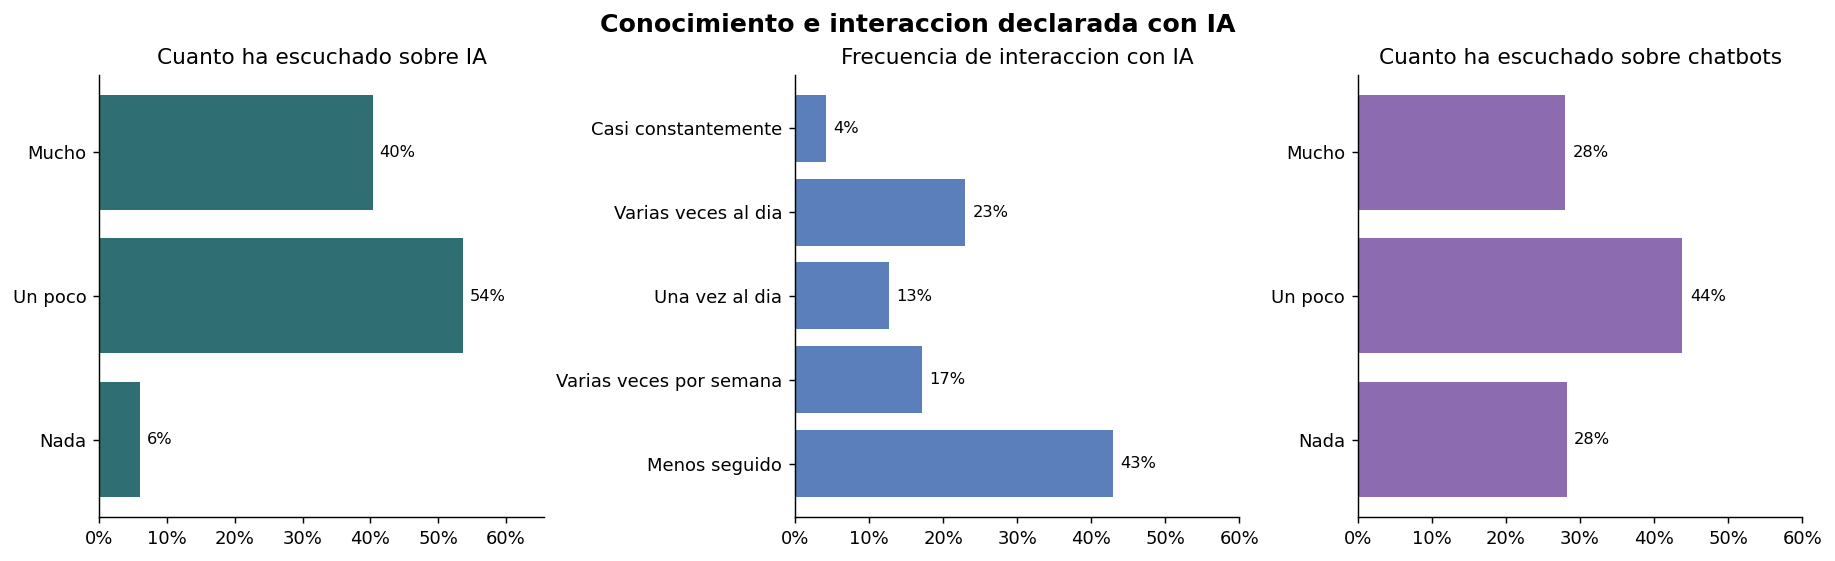

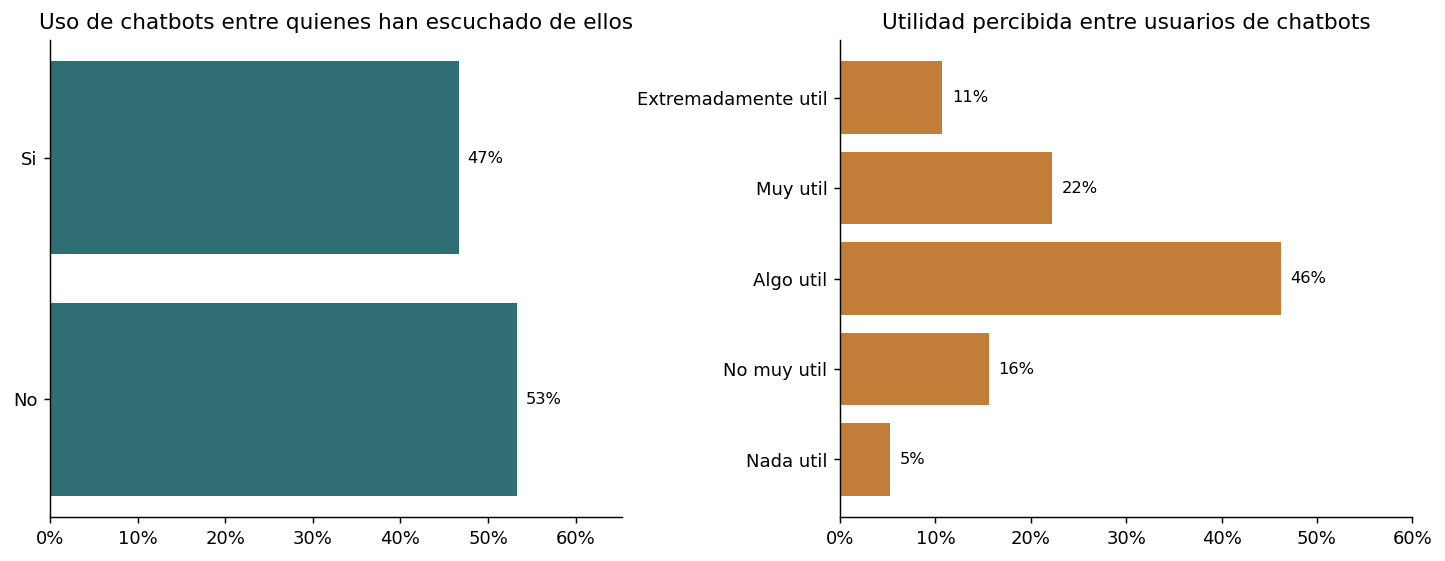

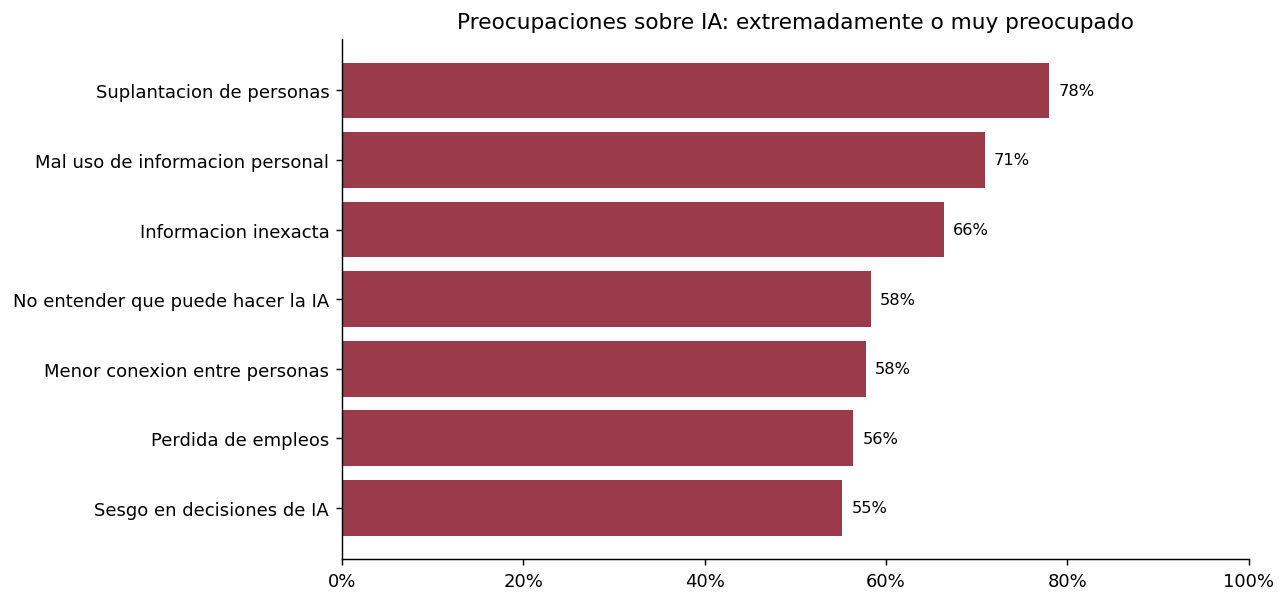

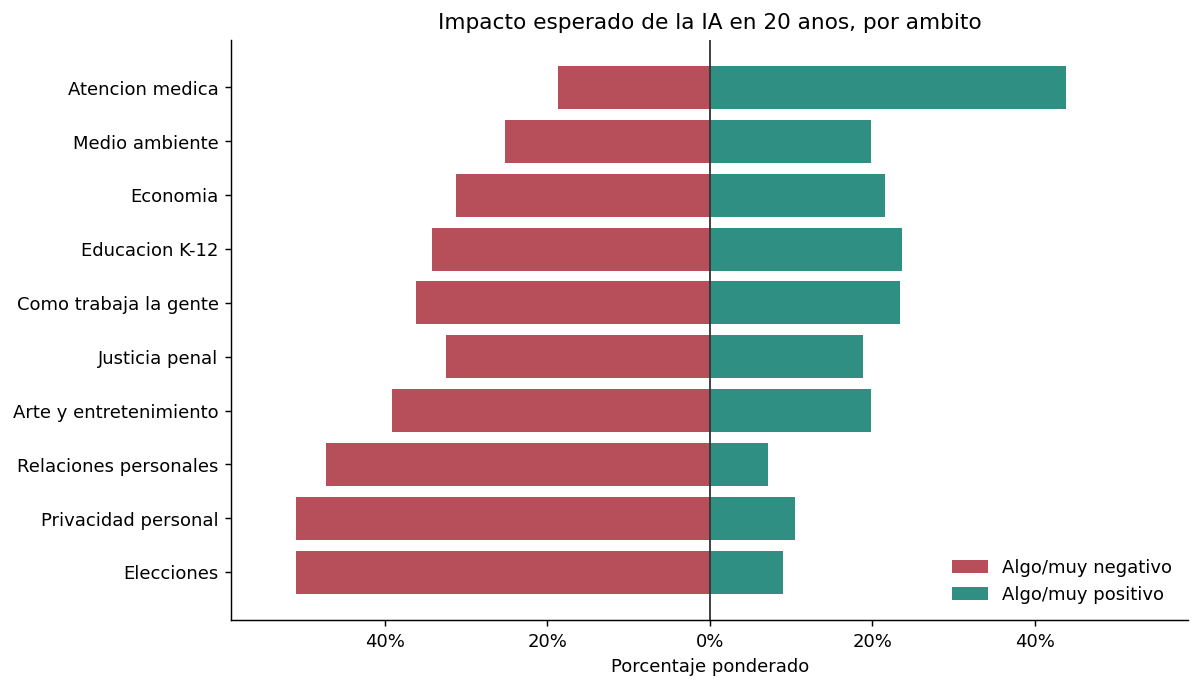

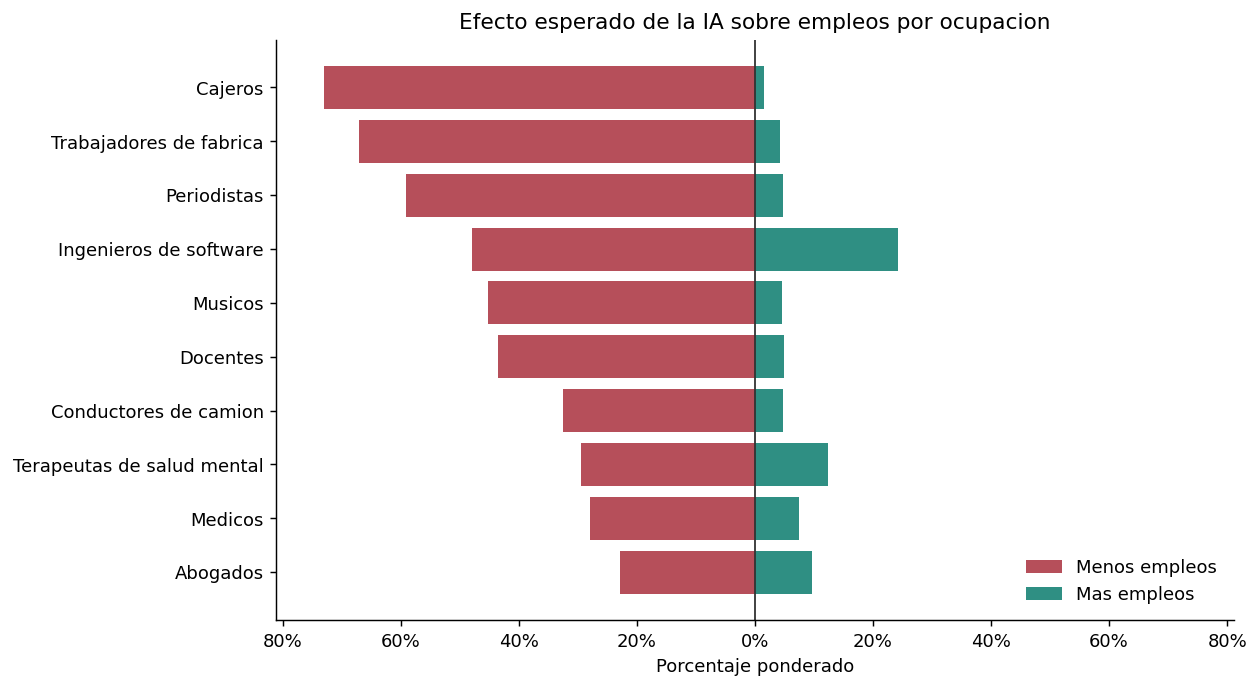

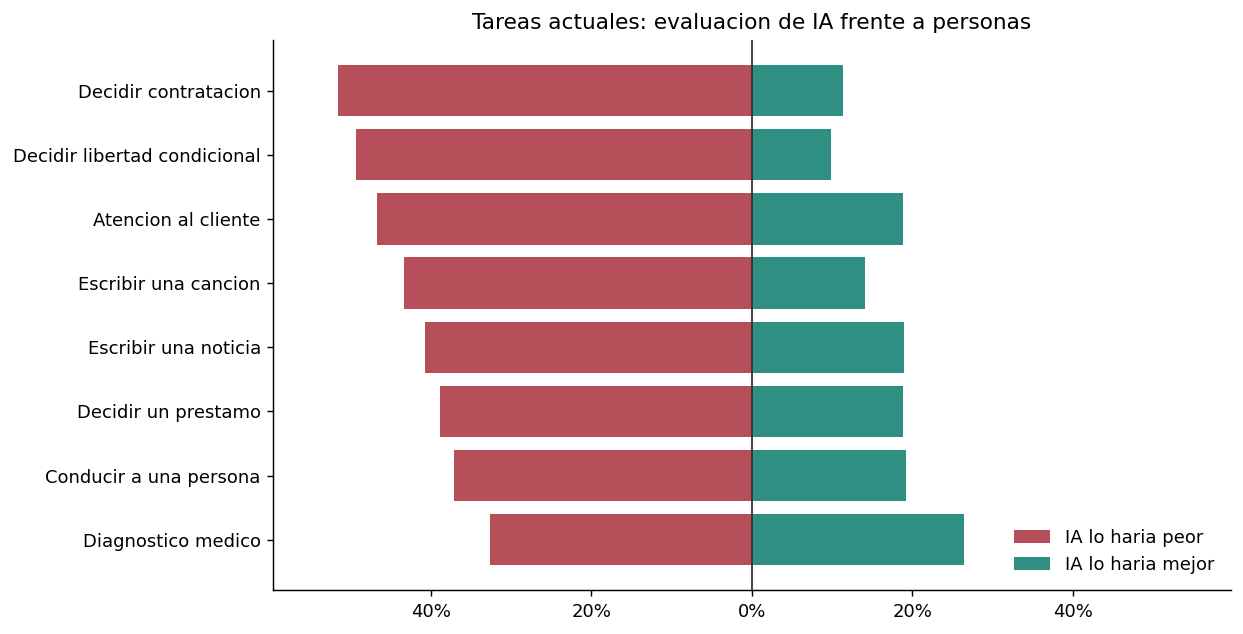

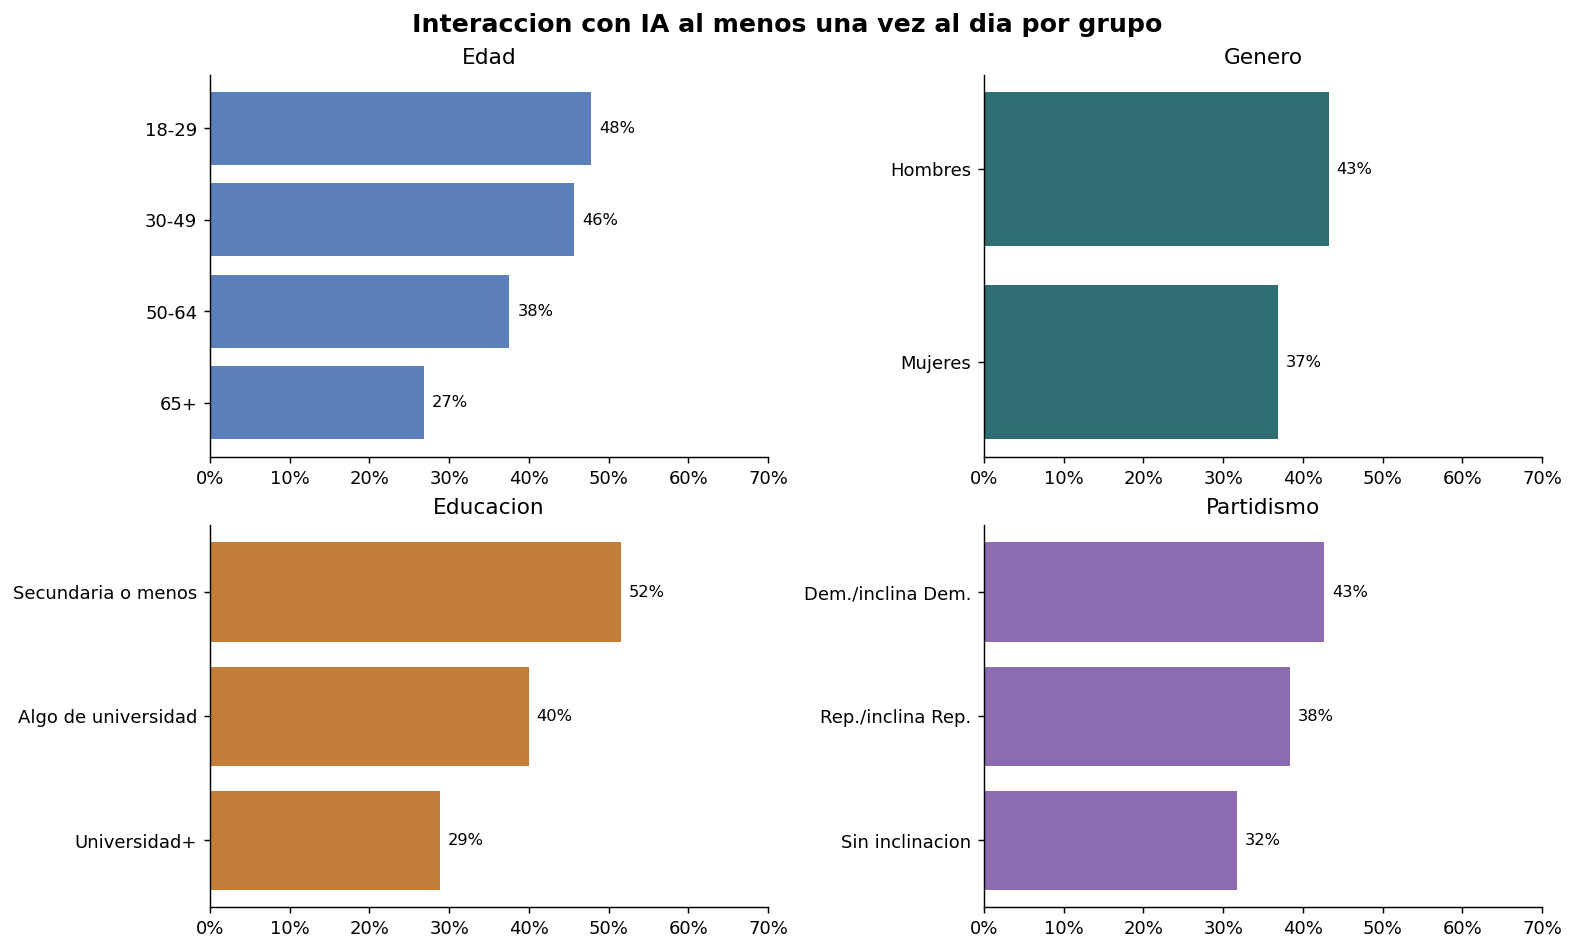

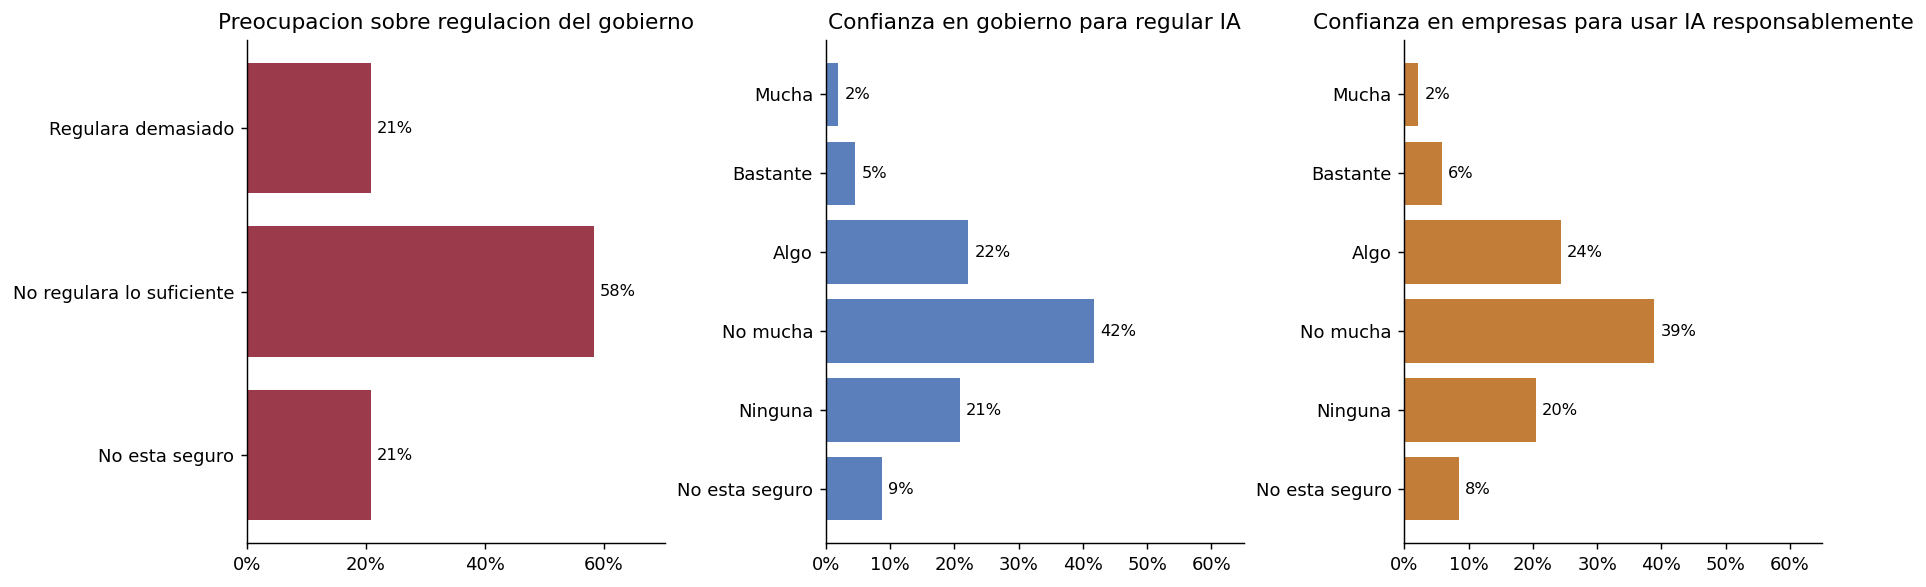

In [2]:

# 1. Familiaridad, uso general y chatbots
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), constrained_layout=True)
charts = [
    ("AI_HEARD_W152", "Cuanto ha escuchado sobre IA"),
    ("USEAI_W152", "Frecuencia de interaccion con IA"),
    ("CHATAWARE_W152", "Cuanto ha escuchado sobre chatbots"),
]
colors = ["#2f6f73", "#5b7fba", "#8c6bb1"]
for ax, (col, title), color in zip(axes, charts, colors):
    tab = weighted_pct(raw, col, single_labels[col])
    ax.barh(tab["respuesta"], tab["porcentaje"], color=color)
    ax.set_title(title)
    ax.set_xlim(0, max(60, tab["porcentaje"].max() + 12))
    ax.xaxis.set_major_formatter(PercentFormatter(100))
    ax.invert_yaxis()
    add_bar_labels(ax)
fig.suptitle("Conocimiento e interaccion declarada con IA", fontsize=14, weight="bold")
fig.savefig(OUTPUT_DIR / "01_conocimiento_uso_ia.png", bbox_inches="tight")
plt.show()

# 2. Experiencia con chatbots, respetando universos condicionados
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
heard_chatbot = clean_series(raw["CHATAWARE_W152"]).isin([1, 2])
used_chatbot = clean_series(raw["CHATUSE_W152"]).eq(1)
for ax, col, title, mask, color in [
    (axes[0], "CHATUSE_W152", "Uso de chatbots entre quienes han escuchado de ellos", heard_chatbot, "#2f6f73"),
    (axes[1], "CHATHELPFUL_W152", "Utilidad percibida entre usuarios de chatbots", used_chatbot, "#c27d38"),
]:
    tab = weighted_pct(raw, col, single_labels[col], denominator=mask)
    ax.barh(tab["respuesta"], tab["porcentaje"], color=color)
    ax.set_xlim(0, max(60, tab["porcentaje"].max() + 12))
    ax.xaxis.set_major_formatter(PercentFormatter(100))
    ax.set_title(title)
    ax.invert_yaxis()
    add_bar_labels(ax)
fig.savefig(OUTPUT_DIR / "02_chatbots_uso_utilidad.png", bbox_inches="tight")
plt.show()

# 3. Preocupaciones: porcentaje extremadamente o muy preocupado
concern = pd.DataFrame([
    {"tema": label, "porcentaje": weighted_share(raw, col, [1, 2])}
    for col, label in concern_items.items()
]).sort_values("porcentaje")
fig, ax = plt.subplots(figsize=(9, 5.2))
ax.barh(concern["tema"], concern["porcentaje"], color="#9b3a4a")
ax.set_title("Preocupaciones sobre IA: extremadamente o muy preocupado")
ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(PercentFormatter(100))
add_bar_labels(ax)
fig.savefig(OUTPUT_DIR / "03_preocupaciones_ia.png", bbox_inches="tight")
plt.show()

# 4. Impacto futuro por ambito: neto positivo versus neto negativo
future = pd.DataFrame([
    {
        "ambito": label,
        "positivo": weighted_share(raw, col, [1, 2]),
        "negativo": weighted_share(raw, col, [4, 5]),
        "no_seguro": weighted_share(raw, col, [6]),
    }
    for col, label in future_items.items()
])
future["neto"] = future["positivo"] - future["negativo"]
future = future.sort_values("neto")
fig, ax = plt.subplots(figsize=(9.5, 5.8))
ax.barh(future["ambito"], -future["negativo"], color="#b64f5a", label="Algo/muy negativo")
ax.barh(future["ambito"], future["positivo"], color="#2f8f83", label="Algo/muy positivo")
ax.axvline(0, color="#333333", linewidth=1)
ax.set_title("Impacto esperado de la IA en 20 anos, por ambito")
ax.set_xlabel("Porcentaje ponderado")
limit = max(future["negativo"].max(), future["positivo"].max()) + 8
ax.set_xlim(-limit, limit)
ax.xaxis.set_major_formatter(lambda x, pos: f"{abs(x):.0f}%")
ax.legend(loc="lower right", frameon=False)
fig.savefig(OUTPUT_DIR / "04_impacto_futuro_ambitos.png", bbox_inches="tight")
plt.show()

# 5. Empleo: mas o menos puestos por ocupacion
jobs = pd.DataFrame([
    {
        "ocupacion": label,
        "mas_empleos": weighted_share(raw, col, [1]),
        "menos_empleos": weighted_share(raw, col, [2]),
        "sin_mucho_cambio": weighted_share(raw, col, [3]),
    }
    for col, label in job_items.items()
]).sort_values("menos_empleos")
fig, ax = plt.subplots(figsize=(9.5, 5.8))
ax.barh(jobs["ocupacion"], -jobs["menos_empleos"], color="#b64f5a", label="Menos empleos")
ax.barh(jobs["ocupacion"], jobs["mas_empleos"], color="#2f8f83", label="Mas empleos")
ax.axvline(0, color="#333333", linewidth=1)
ax.set_title("Efecto esperado de la IA sobre empleos por ocupacion")
ax.set_xlabel("Porcentaje ponderado")
limit = max(jobs["menos_empleos"].max(), jobs["mas_empleos"].max()) + 8
ax.set_xlim(-limit, limit)
ax.xaxis.set_major_formatter(lambda x, pos: f"{abs(x):.0f}%")
ax.legend(loc="lower right", frameon=False)
fig.savefig(OUTPUT_DIR / "05_impacto_empleo_ocupaciones.png", bbox_inches="tight")
plt.show()

# 6. Comparacion humano versus IA en tareas
human = pd.DataFrame([
    {
        "tarea": label,
        "ia_mejor": weighted_share(raw, col, [1]),
        "ia_peor": weighted_share(raw, col, [2]),
        "igual": weighted_share(raw, col, [3]),
    }
    for col, label in human_items.items()
]).sort_values("ia_peor")
fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.barh(human["tarea"], -human["ia_peor"], color="#b64f5a", label="IA lo haria peor")
ax.barh(human["tarea"], human["ia_mejor"], color="#2f8f83", label="IA lo haria mejor")
ax.axvline(0, color="#333333", linewidth=1)
ax.set_title("Tareas actuales: evaluacion de IA frente a personas")
limit = max(human["ia_peor"].max(), human["ia_mejor"].max()) + 8
ax.set_xlim(-limit, limit)
ax.xaxis.set_major_formatter(lambda x, pos: f"{abs(x):.0f}%")
ax.legend(loc="lower right", frameon=False)
fig.savefig(OUTPUT_DIR / "06_humano_vs_ia_tareas.png", bbox_inches="tight")
plt.show()

# 7. Uso al menos diario de IA por grupos demograficos
blocks = [
    ("Edad", weighted_crosstab_share(raw, "F_AGECAT", "USEAI_W152", [1, 2, 3], age_labels), "#5b7fba"),
    ("Genero", weighted_crosstab_share(raw, "F_GENDER", "USEAI_W152", [1, 2, 3], gender_labels), "#2f6f73"),
    ("Educacion", weighted_crosstab_share(raw, "F_EDUCCAT", "USEAI_W152", [1, 2, 3], edu_labels), "#c27d38"),
    ("Partidismo", weighted_crosstab_share(raw, "F_PARTYSUM_FINAL", "USEAI_W152", [1, 2, 3], party_labels), "#8c6bb1"),
]
fig, axes = plt.subplots(2, 2, figsize=(12, 7.2), constrained_layout=True)
for ax, (title, tab, color) in zip(axes.flat, blocks):
    tab = tab.sort_values("porcentaje")
    ax.barh(tab["grupo"], tab["porcentaje"], color=color)
    ax.set_xlim(0, 70)
    ax.xaxis.set_major_formatter(PercentFormatter(100))
    ax.set_title(title)
    add_bar_labels(ax)
fig.suptitle("Interaccion con IA al menos una vez al dia por grupo", fontsize=14, weight="bold")
fig.savefig(OUTPUT_DIR / "07_uso_diario_por_grupos.png", bbox_inches="tight")
plt.show()

# 8. Regulacion y confianza institucional
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), constrained_layout=True)
for ax, col, title, color in [
    (axes[0], "AIREG_W152", "Preocupacion sobre regulacion del gobierno", "#9b3a4a"),
    (axes[1], "REGCONFG_W152", "Confianza en gobierno para regular IA", "#5b7fba"),
    (axes[2], "REGCONFI_W152", "Confianza en empresas para usar IA responsablemente", "#c27d38"),
]:
    tab = weighted_pct(raw, col, single_labels[col])
    ax.barh(tab["respuesta"], tab["porcentaje"], color=color)
    ax.set_xlim(0, max(65, tab["porcentaje"].max() + 12))
    ax.xaxis.set_major_formatter(PercentFormatter(100))
    ax.set_title(title)
    ax.invert_yaxis()
    add_bar_labels(ax)
fig.savefig(OUTPUT_DIR / "08_regulacion_confianza.png", bbox_inches="tight")
plt.show()


## Vista rapida de los PNG

![Conocimiento y uso](data_2/graficos_percepcion_ia/01_conocimiento_uso_ia.png)

![Uso y utilidad de chatbots](data_2/graficos_percepcion_ia/02_chatbots_uso_utilidad.png)

![Preocupaciones sobre IA](data_2/graficos_percepcion_ia/03_preocupaciones_ia.png)

![Impacto futuro por ambito](data_2/graficos_percepcion_ia/04_impacto_futuro_ambitos.png)

![Impacto en empleo por ocupacion](data_2/graficos_percepcion_ia/05_impacto_empleo_ocupaciones.png)

![Humano versus IA](data_2/graficos_percepcion_ia/06_humano_vs_ia_tareas.png)

![Uso diario por grupos](data_2/graficos_percepcion_ia/07_uso_diario_por_grupos.png)

![Regulacion y confianza](data_2/graficos_percepcion_ia/08_regulacion_confianza.png)

## Tablas de control

Estas tablas permiten comprobar rapidamente que las proporciones ponderadas coinciden con el sentido de los graficos.

In [3]:

# Tablas resumen usadas por los graficos principales
resumen = {
    "ha_escuchado_ia": weighted_pct(raw, "AI_HEARD_W152", single_labels["AI_HEARD_W152"]),
    "uso_ia": weighted_pct(raw, "USEAI_W152", single_labels["USEAI_W152"]),
    "impacto_general_20_anios": weighted_pct(raw, "AICHANGE_W152", single_labels["AICHANGE_W152"]),
    "empleo_general": weighted_pct(raw, "AIJOBS_W152", single_labels["AIJOBS_W152"]),
}
for nombre, tabla in resumen.items():
    print("\n" + nombre)
    display(tabla.round({"porcentaje": 1}))



ha_escuchado_ia


,code,porcentaje,respuesta
0,1,40.4,Mucho
1,2,53.6,Un poco
2,3,6.0,Nada



uso_ia


,code,porcentaje,respuesta
0,1,4.2,Casi constantemente
1,2,23.0,Varias veces al dia
2,3,12.7,Una vez al dia
3,4,17.2,Varias veces por semana
4,5,42.9,Menos seguido



impacto_general_20_anios


,code,porcentaje,respuesta
0,1,4.5,Muy positivo
1,2,12.2,Algo positivo
2,3,33.0,Positivo y negativo
3,4,19.5,Algo negativo
4,5,15.3,Muy negativo
5,6,15.5,No esta seguro



empleo_general


,code,porcentaje,respuesta
0,1,5.1,Mas empleos
1,2,64.1,Menos empleos
2,3,14.4,No cambiara mucho
3,4,16.4,No esta seguro
